# minimal-zoom-fft 2/3: What it computes

*The definition, the equivalence with zero-padding, Bluestein's algorithm, and every convention of the library, each drawn and then checked against explicit summation.*

Series: [1. Why](01_why_zoom_fft.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

Each section has one figure and one block of checks. `check(name, a, b)` prints the largest absolute difference between two tensors, evaluated in float64, and stores it in the table at the end. `fwd_matrix` writes the transform as an explicit matrix from its definition, as in `tests/test_zoom.py`. It takes its frequencies from `zoom_freq`, which section 4 compares with `torch.fft.fftfreq` and prints, and nothing else from the implementation.

In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from minimal_zoom_fft import zoom_fft, zoom_ifft, zoom_freq, czt

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.titlesize": 9.5, "image.cmap": "gray",
})
torch.manual_seed(0)
print("torch", torch.__version__)

PI = math.pi
F64, C64, C128 = torch.float64, torch.complex64, torch.complex128
BLUE, ORANGE, AQUA, YELLOW, PINK = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
# colour roles: blue = DFT / torch.fft, orange = zero-padded FFT, aqua = zoom_fft, yellow = the DTFT

CHECKS = []

def err(a, b):
    a, b = torch.as_tensor(a).detach().cpu().to(C128), torch.as_tensor(b).detach().cpu().to(C128)
    return (a - b).abs().max().item()

def check(name, a, b, label=None):
    e = err(a, b)
    label = label or str(torch.as_tensor(a).dtype).replace("torch.", "")
    CHECKS.append((name, label, f"{e:.2e}"))
    print(f"{name:<50s} {label:<11s} max|err| = {e:.2e}")

def note(name, label, value):
    CHECKS.append((name, label, value))
    print(f"{name:<50s} {label:<11s} {value}")

def fwd_matrix(n_in, n_out, k_start, k_end, include_end=False, c=0.0):
    # E[m, n] = exp(-i w_m (n - c)) in float64, so that X = E @ x
    w = zoom_freq(n_out, k_start, k_end, include_end)
    n = torch.arange(n_in, dtype=F64) - c
    return torch.exp(-1j * w[:, None] * n[None, :])

def dtft(x, w):
    # the DTFT of x at arbitrary frequencies w, by explicit summation
    return torch.exp(-1j * w[:, None] * torch.arange(x.shape[-1], dtype=F64)[None, :]) @ x.to(C128)

def arrow(fig, a, b, text="", dy=0.05):
    # an arrow from the right edge of axes a to the left edge of axes b, in figure coordinates
    pa, pb = a.get_position(), b.get_position()
    y = (pa.y0 + pa.y1) / 2
    fig.patches.append(FancyArrowPatch((pa.x1 + 0.004, y), (pb.x0 - 0.004, y), transform=fig.transFigure,
                                       arrowstyle="-|>", mutation_scale=11, color="0.45", lw=1.0))
    fig.text((pa.x1 + pb.x0) / 2, y + dy, text, ha="center", va="bottom", fontsize=7.5, color="0.35")

torch 2.14.0


## 1. The definition

The DTFT of $N$ samples is a continuous function of the frequency, and the DFT reads it at $N$ equispaced points of the circle. `zoom_fft` reads it at $M$ points of a chosen band $[k_\mathrm{start}, k_\mathrm{end}]$,

$$X[m] = \sum_{n=0}^{N-1} x[n]\, e^{-i\omega_m (n - c)}, \qquad \omega_m = k_\mathrm{start} + m\,\Delta,$$

with $\Delta$ the band step and $c$ the origin of the grid (both in section 4). `zoom_freq` returns the $\omega_m$. The record used throughout is two tones at 10.4 and 13.1 bins of $N = 32$ samples.

DFT == DTFT at w = 2 pi k / N                      complex128  max|err| = 1.05e-13
zoom_fft == E x (explicit summation)               complex128  max|err| = 3.19e-13
zoom_fft == E x, complex64 input                   complex64   max|err| = 8.16e-06


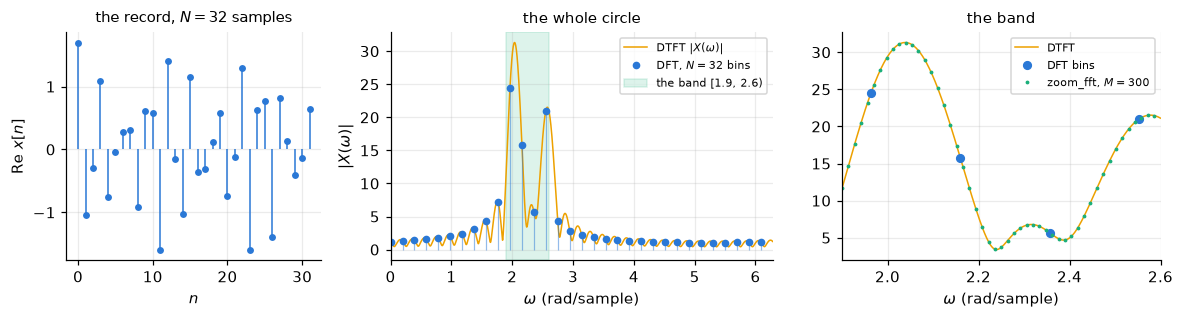

In [2]:
N = 32
n_idx = torch.arange(N, dtype=F64)
x = torch.exp(2j * PI * 10.4 * n_idx / N) + 0.7 * torch.exp(2j * PI * 13.1 * n_idx / N)

w_dense = torch.linspace(0, 2 * PI, 4001, dtype=F64)[:-1]
X_dense = dtft(x, w_dense)                                     # the DTFT, densely sampled
w_dft, X_dft = zoom_freq(N), torch.fft.fft(x)                  # the DFT: N bins, 2 pi k / N
M, ka, kb = 300, 1.9, 2.6                                      # a band, sampled at M points
w_zoom, X_zoom = zoom_freq(M, ka, kb), zoom_fft(x, M, ka, kb, norm="backward")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.0), gridspec_kw={"width_ratios": [0.8, 1.2, 1]})
ax = axes[0]
ax.vlines(n_idx, 0, x.real, color=BLUE, lw=1)
ax.plot(n_idx, x.real, "o", ms=3.5, color=BLUE)
ax.set(xlabel="$n$", ylabel="Re $x[n]$", title=f"the record, $N = {N}$ samples")

ax = axes[1]
ax.plot(w_dense, X_dense.abs(), color=YELLOW, lw=1, label=r"DTFT $|X(\omega)|$")
ax.vlines(w_dft, 0, X_dft.abs(), color=BLUE, lw=0.8, alpha=0.5)
ax.plot(w_dft, X_dft.abs(), "o", ms=4, color=BLUE, label=f"DFT, $N = {N}$ bins")
ax.axvspan(ka, kb, color=AQUA, alpha=0.15, label=f"the band [{ka}, {kb})")
ax.set(xlim=(0, 2 * PI), xlabel=r"$\omega$ (rad/sample)", ylabel=r"$|X(\omega)|$", title="the whole circle")
ax.legend(fontsize=7.5)

ax = axes[2]
sel = (w_dense >= ka) & (w_dense <= kb)
ax.plot(w_dense[sel], X_dense[sel].abs(), color=YELLOW, lw=1, label="DTFT")
sel = (w_dft >= ka) & (w_dft <= kb)
ax.plot(w_dft[sel], X_dft[sel].abs(), "o", ms=5, color=BLUE, label="DFT bins")
ax.plot(w_zoom, X_zoom.abs(), ".", ms=3, markevery=6, color=AQUA, label=f"zoom_fft, $M = {M}$")
ax.set(xlim=(ka, kb), xlabel=r"$\omega$ (rad/sample)", title="the band")
ax.legend(fontsize=7.5)
fig.tight_layout()

check("DFT == DTFT at w = 2 pi k / N", X_dft, dtft(x, w_dft))
check("zoom_fft == E x (explicit summation)", X_zoom, fwd_matrix(N, M, ka, kb) @ x)
check("zoom_fft == E x, complex64 input", zoom_fft(x.to(C64), M, ka, kb, norm="backward"),
      fwd_matrix(N, M, ka, kb) @ x, label="complex64")

Zooming samples the DTFT of the record we have. It adds no resolution: the two tones are 2.7 bins apart and would stay merged however fine the step if they were closer than the width of a DTFT peak.

## 2. Zero-padding computes the same samples

Padding the record with $L - N$ zeros does not change the sum, so `fft(x, n=L)` reads the DTFT at $\omega = 2\pi k / L$. Keeping $M$ of those bins is a zoom with step $2\pi / L$, anchored on a bin. The two routes below produce the same 48 numbers; the padded one transforms $L = 256$ samples and discards 208 of the 256 results.

zoom_fft == fft(x, n=256)[70:118]                  complex128  max|err| = 3.35e-14
zoom_fft == fft(x, n=1024)[300:364]                complex128  max|err| = 2.56e-14
zoom_fft == fft(x, n=97)[11:41]                    complex128  max|err| = 1.42e-13

the band of section 1 has step 2.333e-03 rad/sample: 2 pi / step = 2692.8, not an integer, so no padding length L produces it


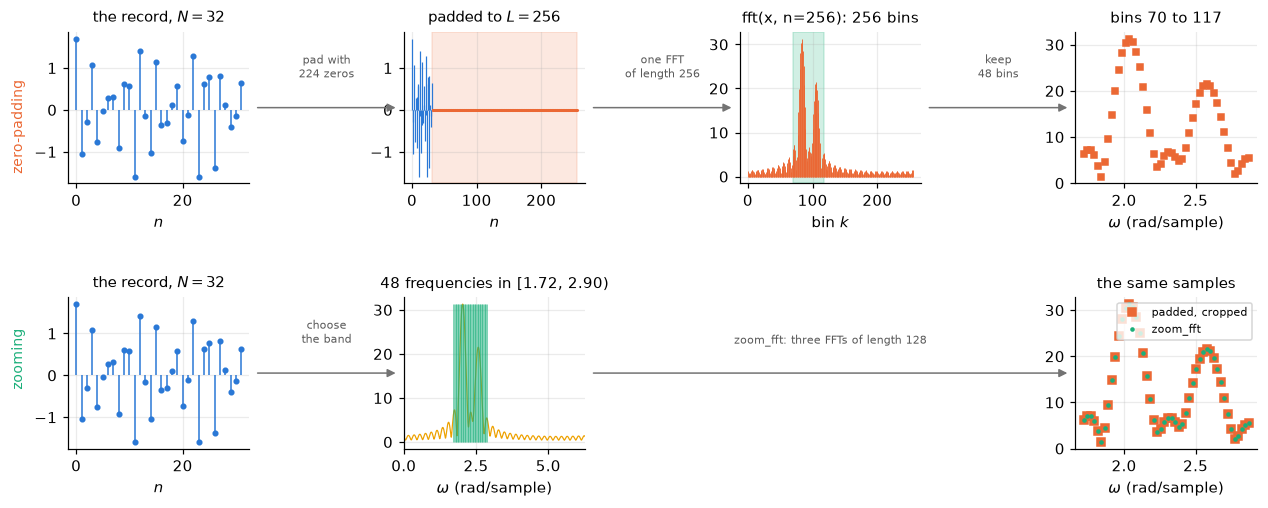

In [3]:
L, M2, k_first = 256, 48, 70                                    # pad to L, keep bins k_first .. k_first + M2 - 1
x_pad = torch.cat([x, torch.zeros(L - N, dtype=C128)])
X_pad = torch.fft.fft(x_pad)
crop = slice(k_first, k_first + M2)
k0 = 2 * PI * k_first / L
X_zoom2 = zoom_fft(x, M2, k0, k0 + 2 * PI * M2 / L, norm="backward")
w_pad, w_zoom2 = zoom_freq(L), zoom_freq(M2, k0, k0 + 2 * PI * M2 / L)

fig, axes = plt.subplots(2, 4, figsize=(11.5, 4.8))
fig.subplots_adjust(wspace=0.85, hspace=0.75, left=0.05, right=0.99, top=0.9, bottom=0.11)
for ax in axes[:, 0]:
    ax.vlines(n_idx, 0, x.real, color=BLUE, lw=1); ax.plot(n_idx, x.real, "o", ms=3, color=BLUE)
    ax.set(xlabel="$n$", title=f"the record, $N = {N}$")

ax = axes[0, 1]
ax.axvspan(N - 0.5, L - 0.5, color=ORANGE, alpha=0.15)
ax.vlines(torch.arange(L), 0, x_pad.real, color=BLUE, lw=0.8)
ax.plot(torch.arange(N, L), torch.zeros(L - N), ".", ms=2, color=ORANGE)
ax.set(xlabel="$n$", title=f"padded to $L = {L}$")

ax = axes[0, 2]
ax.axvspan(k_first - 0.5, k_first + M2 - 0.5, color=AQUA, alpha=0.2)
ax.vlines(torch.arange(L), 0, X_pad.abs(), color=ORANGE, lw=0.6)
ax.set(xlabel="bin $k$", title=f"fft(x, n={L}): {L} bins")

ax = axes[0, 3]
ax.plot(w_pad[crop], X_pad[crop].abs(), "s", ms=4, color=ORANGE)
ax.set(xlabel=r"$\omega$ (rad/sample)", title=f"bins {k_first} to {k_first + M2 - 1}")

ax = axes[1, 1]
ax.plot(w_dense, X_dense.abs(), color=YELLOW, lw=0.8)
ax.vlines(w_zoom2, 0, X_dense.abs().max(), color=AQUA, lw=0.6, alpha=0.6)
ax.set(xlim=(0, 2 * PI), xlabel=r"$\omega$ (rad/sample)", title=f"{M2} frequencies in [{k0:.2f}, {k0 + 2 * PI * M2 / L:.2f})")
axes[1, 2].axis("off")
ax = axes[1, 3]
ax.plot(w_pad[crop], X_pad[crop].abs(), "s", ms=5, color=ORANGE, label="padded, cropped")
ax.plot(w_zoom2, X_zoom2.abs(), ".", ms=4, color=AQUA, label="zoom_fft")
ax.set(xlabel=r"$\omega$ (rad/sample)", title="the same samples"); ax.legend(fontsize=7)

arrow(fig, axes[0, 0], axes[0, 1], f"pad with\n{L - N} zeros")
arrow(fig, axes[0, 1], axes[0, 2], f"one FFT\nof length {L}")
arrow(fig, axes[0, 2], axes[0, 3], f"keep\n{M2} bins")
arrow(fig, axes[1, 0], axes[1, 1], "choose\nthe band")
arrow(fig, axes[1, 1], axes[1, 3], f"zoom_fft: three FFTs of length {1 << (N + M2 - 2).bit_length()}")
fig.text(0.005, 0.72, "zero-padding", rotation=90, va="center", fontsize=9, color=ORANGE)
fig.text(0.005, 0.28, "zooming", rotation=90, va="center", fontsize=9, color=AQUA)

check(f"zoom_fft == fft(x, n={L})[{k_first}:{k_first + M2}]", X_zoom2, X_pad[crop])
for L_, k_, M_ in [(1024, 300, 64), (97, 11, 30)]:
    k0_ = 2 * PI * k_ / L_
    check(f"zoom_fft == fft(x, n={L_})[{k_}:{k_ + M_}]",
          zoom_fft(x, M_, k0_, k0_ + 2 * PI * M_ / L_, norm="backward"), torch.fft.fft(x, n=L_)[k_:k_ + M_])
step = (kb - ka) / M
print(f"\nthe band of section 1 has step {step:.3e} rad/sample: 2 pi / step = {2 * PI / step:.1f}, "
      f"not an integer, so no padding length L produces it")

## 3. How it is computed: the chirp Z-transform

`czt` evaluates $X[k] = \sum_n x[n]\, e^{-i a n}\, e^{i w n k}$; `zoom_fft` is the case $a = k_\mathrm{start}$, $w = -\Delta$. Bluestein's identity $nk = \tfrac{1}{2}(n^2 + k^2 - (k - n)^2)$ turns the sum into a linear convolution of the chirped signal $x[n]\, e^{-i a n}\, e^{i w n^2/2}$ with the chirp $e^{-i w j^2/2}$, followed by a second multiplication by $e^{i w k^2/2}$. Three FFTs of length $\mathrm{nextpow2}(N + M - 1)$ compute the convolution, whatever the band.

Bluestein re-derivation == O(NM) sum               complex128  max|err| = 4.38e-13
library czt == O(NM) sum                           complex128  max|err| = 5.83e-13
zoom_fft == czt(w=-step, a=k_start) x ramp         complex128  max|err| = 8.88e-16

N = 32, M = 45: three FFTs of length 128


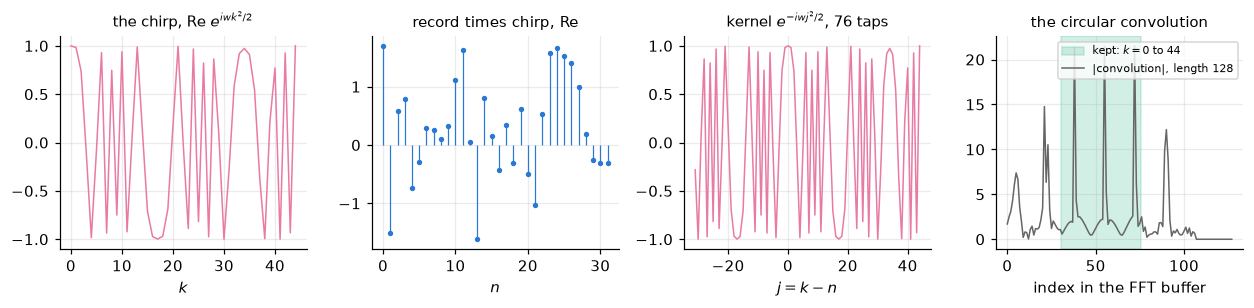

In [4]:
def bluestein_czt(x, m, w, a):
    # X[k] = sum_n x[n] exp(-i a n) exp(i w n k), k = 0..m-1, by linear convolution; returns the
    # intermediate convolution too, for the figure
    n = x.shape[-1]
    n_fft = 1 << (n + m - 2).bit_length()
    j = torch.arange(max(n, m), dtype=F64)
    chirp = torch.exp(1j * w * j ** 2 / 2)
    pre = x.to(C128) * chirp[:n] * torch.exp(-1j * a * j[:n])
    kernel = torch.cat([chirp[1:n].flip(0), chirp[:m]]).conj()          # j = -(n-1) .. m-1
    conv = torch.fft.ifft(torch.fft.fft(pre, n=n_fft) * torch.fft.fft(kernel, n=n_fft))
    return conv[..., n - 1:n - 1 + m] * chirp[:m], (chirp, pre, kernel, conv)

w_p, a_p, M_p = 0.37, -1.1, 45
X_bl, (chirp, pre, kernel, conv) = bluestein_czt(x, M_p, w_p, a_p)
k_p = torch.arange(M_p, dtype=F64)
brute = (x[None, :] * torch.exp(-1j * a_p * n_idx)[None, :] * torch.exp(1j * w_p * n_idx[None, :] * k_p[:, None])).sum(-1)
n_fft = len(conv)

fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.9))
ax = axes[0]
ax.plot(chirp.real, color=PINK, lw=1)
ax.set(xlabel="$k$", title=r"the chirp, Re $e^{i w k^2/2}$")
ax = axes[1]
ax.vlines(n_idx, 0, pre.real, color=BLUE, lw=0.8); ax.plot(n_idx, pre.real, "o", ms=2.5, color=BLUE)
ax.set(xlabel="$n$", title="record times chirp, Re")
ax = axes[2]
jj = torch.arange(-(N - 1), M_p)
ax.plot(jj, kernel.real, color=PINK, lw=1)
ax.set(xlabel="$j = k - n$", title=f"kernel $e^{{-i w j^2/2}}$, {len(jj)} taps")
ax = axes[3]
ax.axvspan(N - 1 - 0.5, N - 1 + M_p - 0.5, color=AQUA, alpha=0.2, label=f"kept: $k = 0$ to ${M_p - 1}$")
ax.plot(conv.abs(), color="0.4", lw=1, label=f"|convolution|, length {n_fft}")
ax.set(xlabel="index in the FFT buffer", title="the circular convolution")
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout()

check("Bluestein re-derivation == O(NM) sum", X_bl, brute)
check("library czt == O(NM) sum", czt(x, M_p, w_p, a_p), brute)
Mz, kz0, kz1, c_org = 51, -0.37, 1.234, 7.5
check("zoom_fft == czt(w=-step, a=k_start) x ramp",
      zoom_fft(x, Mz, kz0, kz1, norm="backward", center=c_org),
      czt(x, Mz, w_phase=-(kz1 - kz0) / Mz, a_phase=kz0) * torch.exp(1j * c_org * zoom_freq(Mz, kz0, kz1)))
print(f"\nN = {N}, M = {M_p}: three FFTs of length {n_fft}")

The chirp phase $w k^2 / 2$ grows quadratically and reaches thousands of radians for a few thousand samples, more than float32 resolves. `core.py` evaluates it in float64, reduces it modulo $2\pi$ and only then casts to the working precision. Notebook 3 measures what that is worth.

## 4. Conventions

The band is sampled like FFT bins when `include_end=False`: the $M$ samples are spaced by $(k_\mathrm{end} - k_\mathrm{start}) / M$ and the right end is excluded, so $[0, 2\pi)$ with $M = N$ is the DFT. Its `fftshift` is the full band that starts at $-2\pi\,(N // 2) / N$, which is $[-\pi, \pi)$ for even $N$ (the record here has $N = 32$) and half a bin above it for odd $N$. With `include_end=True` the last sample sits on $k_\mathrm{end}$, $M - 1$ steps from the first.

zoom_fft(x) == fft(x, norm='ortho')                complex128  max|err| = 6.98e-15
band [-pi, pi) == fftshift(fft(x))                 complex128  max|err| = 1.55e-14
zoom_freq(8) == 2 pi fftfreq(8) mod 2 pi           float64     max|err| = 0.00e+00
include_end=True == explicit summation             complex128  max|err| = 4.34e-14
zoom_freq(5, -1, 1)       = [-1.0, -0.6, -0.2, 0.2, 0.6]
zoom_freq(5, -1, 1, True) = [-1.0, -0.5, 0.0, 0.5, 1.0]


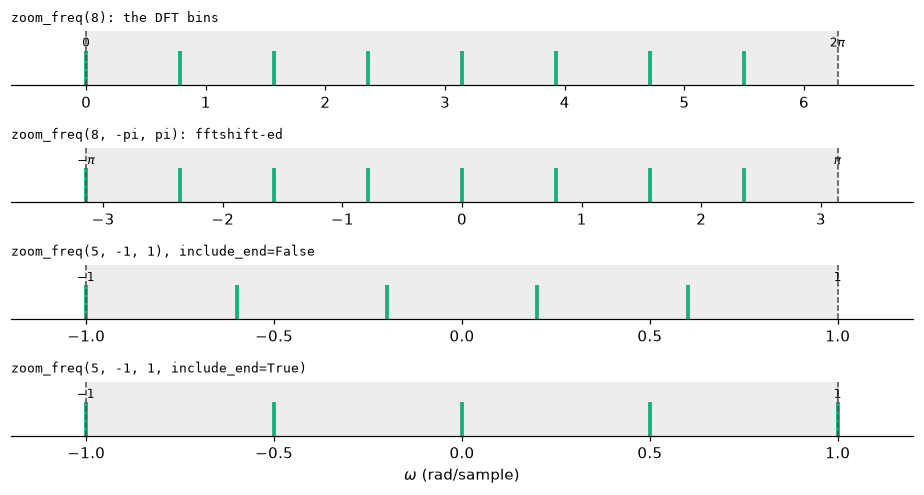

In [5]:
rows = [("zoom_freq(8): the DFT bins", zoom_freq(8), 0, 2 * PI, r"$0$", r"$2\pi$"),
        ("zoom_freq(8, -pi, pi): fftshift-ed", zoom_freq(8, -PI, PI), -PI, PI, r"$-\pi$", r"$\pi$"),
        ("zoom_freq(5, -1, 1), include_end=False", zoom_freq(5, -1.0, 1.0), -1, 1, "$-1$", "$1$"),
        ("zoom_freq(5, -1, 1, include_end=True)", zoom_freq(5, -1.0, 1.0, True), -1, 1, "$-1$", "$1$")]
fig, axes = plt.subplots(len(rows), 1, figsize=(8.5, 4.6))
for ax, (title, w, k0, k1, l0, l1) in zip(axes, rows):
    ax.axvspan(k0, k1, color="0.93", zorder=0)
    ax.vlines(w, 0, 1, color=AQUA, lw=2.5)
    for v, lab in [(k0, l0), (k1, l1)]:
        ax.axvline(v, color="0.3", lw=1, ls="--"); ax.text(v, 1.12, lab, ha="center", fontsize=8)
    ax.set(xlim=(k0 - 0.1 * (k1 - k0), k1 + 0.1 * (k1 - k0)), ylim=(0, 1.6), yticks=[])
    ax.set_title(title, loc="left", fontsize=8.5, family="monospace")
    ax.grid(False); ax.spines["left"].set_visible(False)
axes[-1].set_xlabel(r"$\omega$ (rad/sample)")
fig.tight_layout()

check("zoom_fft(x) == fft(x, norm='ortho')", zoom_fft(x), torch.fft.fft(x, norm="ortho"))
check("band [-pi, pi) == fftshift(fft(x))", zoom_fft(x, k_start=-PI, k_end=PI), torch.fft.fftshift(torch.fft.fft(x, norm="ortho")))
check("zoom_freq(8) == 2 pi fftfreq(8) mod 2 pi", zoom_freq(8), torch.remainder(2 * PI * torch.fft.fftfreq(8, dtype=F64), 2 * PI))
check("include_end=True == explicit summation", zoom_fft(x, 7, -1.0, 1.0, norm="backward", include_end=True),
      fwd_matrix(N, 7, -1.0, 1.0, include_end=True) @ x)
print("zoom_freq(5, -1, 1)       =", [round(v, 2) for v in zoom_freq(5, -1.0, 1.0).tolist()])
print("zoom_freq(5, -1, 1, True) =", [round(v, 2) for v in zoom_freq(5, -1.0, 1.0, True).tolist()])

The origin of the grid is the index $c$ given by `center`: `False` is sample 0 as in `torch.fft`, `True` is $N // 2$ as in `fftshift`, and a float pins it anywhere, for example the half-integer $(N - 1)/2$ that `psf_generator` uses for an even grid. Since $e^{-i\omega_m (n - c)} = e^{i c\,\omega_m}\, e^{-i\omega_m n}$, the origin only multiplies the output by a phase ramp of slope $c$. It leaves $|X|$ unchanged and matters when fields are added coherently.

center=True == fft(ifftshift(x)), full band        complex128  max|err| = 1.18e-14
center=True: zoom_ifft == fftshift(ifft(X))        complex128  max|err| = 6.89e-15
center=(N-1)/2 == explicit summation               complex128  max|err| = 2.30e-14
center is the ramp exp(+i c w_m)                   complex128  max|err| = 1.23e-16


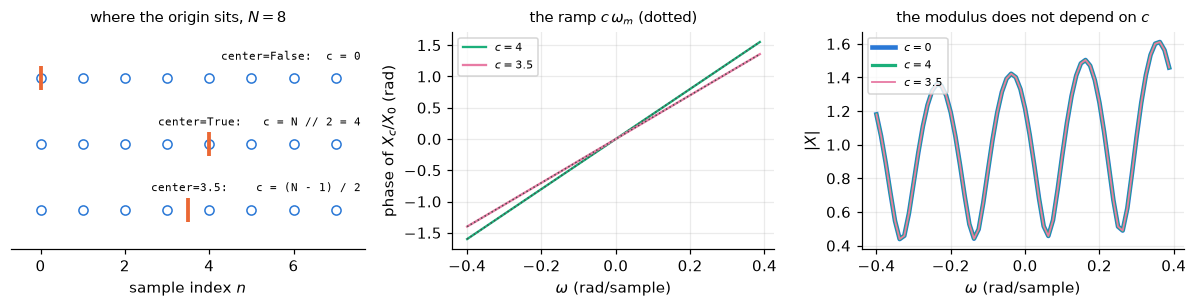

In [6]:
N8 = 8
origins = [("center=False:  c = 0", 0.0), ("center=True:   c = N // 2 = 4", 4.0), ("center=3.5:    c = (N - 1) / 2", 3.5)]
band = dict(k_start=-0.4, k_end=0.4, n_out=64, norm="backward")           # a band narrow enough that c w_m does not wrap
X0 = zoom_fft(x, **band)
w_b = zoom_freq(64, -0.4, 0.4)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9), gridspec_kw={"width_ratios": [1.1, 1, 1]})
ax = axes[0]
for row, (label, c) in enumerate(origins):
    y = 2 - row
    ax.plot(range(N8), [y] * N8, "o", ms=6, color=BLUE, mfc="white")
    ax.plot([c], [y], "|", ms=16, mew=2.5, color=ORANGE)
    ax.text(N8 - 0.4, y + 0.28, label, ha="right", fontsize=7.5, family="monospace")
ax.set(xlim=(-0.7, N8 - 0.3), ylim=(-0.6, 2.7), yticks=[], xlabel="sample index $n$",
       title=f"where the origin sits, $N = {N8}$")
ax.grid(False); ax.spines["left"].set_visible(False)
ax = axes[1]
for label, c in origins[1:]:
    Xc = zoom_fft(x, center=c, **band)
    ax.plot(w_b, torch.angle(Xc / X0), color=AQUA if c == 4 else PINK, label=f"$c = {c:g}$")
    ax.plot(w_b, c * w_b, ":", color="0.3", lw=1)
ax.set(xlabel=r"$\omega$ (rad/sample)", ylabel="phase of $X_c / X_0$ (rad)", title=r"the ramp $c\,\omega_m$ (dotted)")
ax.legend(fontsize=7.5)
ax = axes[2]
for (label, c), col in zip(origins, [BLUE, AQUA, PINK]):
    ax.plot(w_b, zoom_fft(x, center=c, **band).abs(), color=col, lw=3 - 0.9 * origins.index((label, c)), label=f"$c = {c:g}$")
ax.set(xlabel=r"$\omega$ (rad/sample)", ylabel="$|X|$", title="the modulus does not depend on $c$")
ax.legend(fontsize=7.5)
fig.tight_layout()

check("center=True == fft(ifftshift(x)), full band", zoom_fft(x, center=True), torch.fft.fft(torch.fft.ifftshift(x), norm="ortho"))
check("center=True: zoom_ifft == fftshift(ifft(X))", zoom_ifft(x, center=True), torch.fft.fftshift(torch.fft.ifft(x, norm="ortho")))
check("center=(N-1)/2 == explicit summation", zoom_fft(x, Mz, kz0, kz1, norm="backward", center=(N - 1) / 2),
      fwd_matrix(N, Mz, kz0, kz1, c=(N - 1) / 2) @ x)
check("center is the ramp exp(+i c w_m)", zoom_fft(x, Mz, kz0, kz1, center=c_org),
      zoom_fft(x, Mz, kz0, kz1) * torch.exp(1j * c_org * zoom_freq(Mz, kz0, kz1)))

The normalisation follows `torch.fft`. With $M$ band samples, `"backward"` leaves the forward transform unnormalised and divides the inverse by $M$, `"forward"` does the reverse and `"ortho"` puts $1/\sqrt{M}$ on both. On a partial band this is a constant factor.

The inverse direction is `zoom_ifft`, which computes $x[n] = \sum_m X[m]\, e^{+i\omega_m (n - c)}$, the conjugate transpose $E^H$ of the forward matrix over the same band, under mirrored norms. On the full band $E^H E = I$ and the round trip returns $x$. On a partial band the round trip returns the part of $x$ that lives in the band, times $2\pi$ over the band width (3 here, since $M$ samples now cover a third of the circle): a band-pass filter, drawn below. This normal operator $E^H E$ is what a least-squares reconstruction inverts.

norm='backward': zoom_fft == fft, zoom_ifft == ifft complex128  max|err| = 4.31e-14
norm='ortho': zoom_fft == fft, zoom_ifft == ifft   complex128  max|err| = 1.19e-14
norm='forward': zoom_fft == fft, zoom_ifft == ifft complex128  max|err| = 6.75e-14
partial band: norm='forward' is 1/M x 'backward'   complex128  max|err| = 0.00e+00
full band: zoom_ifft(zoom_fft(x)) == x             complex128  max|err| = 5.44e-15
partial band: round trip == E^H E x / M            complex128  max|err| = 4.50e-15
adjoint: <Ex, y> - <x, E^H y>, norm backward/forward complex128  6.76e-15
adjoint: <Ex, y> - <x, E^H y>, norm ortho/ortho    complex128  2.48e-15


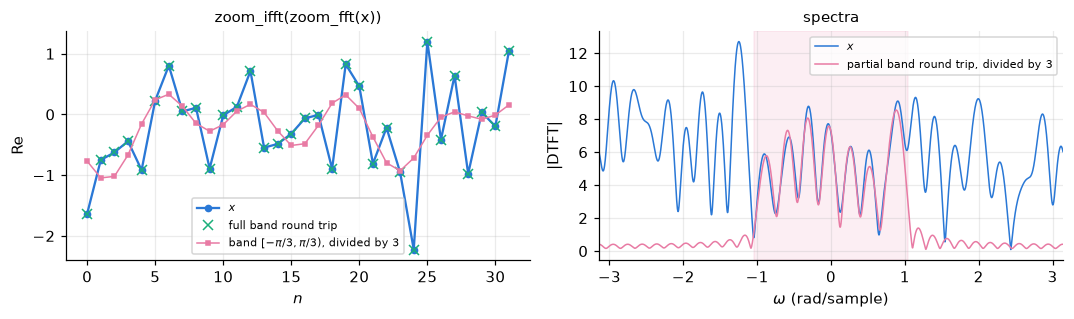

In [7]:
xr = torch.randn(N, dtype=C128)
kw_full = dict(n_out=N)
kw_part = dict(n_out=N, k_start=-PI / 3, k_end=PI / 3)
rt_full = zoom_ifft(zoom_fft(xr, **kw_full), **kw_full)
rt_part = zoom_ifft(zoom_fft(xr, **kw_part), **kw_part)          # norm="ortho" both ways: E^H E / M
w_c = torch.linspace(-PI, PI, 2001, dtype=F64)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
ax = axes[0]
ax.plot(n_idx, xr.real, "o-", ms=4, color=BLUE, label="$x$")
ax.plot(n_idx, rt_full.real, "x", ms=6, color=AQUA, label="full band round trip")
ax.plot(n_idx, rt_part.real / 3, "s-", ms=3, lw=1, color=PINK, label=r"band $[-\pi/3, \pi/3)$, divided by 3")
ax.set(xlabel="$n$", ylabel="Re", title="zoom_ifft(zoom_fft(x))"); ax.legend(fontsize=7.5)
ax = axes[1]
ax.axvspan(-PI / 3, PI / 3, color=PINK, alpha=0.12)
ax.plot(w_c, dtft(xr, w_c).abs(), color=BLUE, lw=1, label="$x$")
ax.plot(w_c, dtft(rt_part, w_c).abs() / 3, color=PINK, lw=1, label="partial band round trip, divided by 3")
ax.set(xlim=(-PI, PI), xlabel=r"$\omega$ (rad/sample)", ylabel="|DTFT|", title="spectra"); ax.legend(fontsize=7.5)
fig.tight_layout()

for nm in ("backward", "ortho", "forward"):
    check(f"norm={nm!r}: zoom_fft == fft, zoom_ifft == ifft",
          torch.stack([zoom_fft(xr, norm=nm), zoom_ifft(xr, norm=nm)]),
          torch.stack([torch.fft.fft(xr, norm=nm), torch.fft.ifft(xr, norm=nm)]))
check("partial band: norm='forward' is 1/M x 'backward'", zoom_fft(x, M, ka, kb, norm="forward"), X_zoom / M)
check("full band: zoom_ifft(zoom_fft(x)) == x", rt_full, xr)
E = fwd_matrix(N, N, -PI / 3, PI / 3)
check("partial band: round trip == E^H E x / M", rt_part, E.conj().T @ (E @ xr) / N)
dot = lambda a, b: complex((a.conj() * b).sum())
xa, ya = torch.randn(11, dtype=C128), torch.randn(7, dtype=C128)
kw = dict(k_start=-0.4, k_end=0.9, center=2.5, include_end=True)
for nf, ni in [("backward", "forward"), ("ortho", "ortho")]:
    lhs, rhs = dot(zoom_fft(xa, 7, norm=nf, **kw), ya), dot(xa, zoom_ifft(ya, 11, norm=ni, **kw))
    note(f"adjoint: <Ex, y> - <x, E^H y>, norm {nf}/{ni}", "complex128", f"{abs(lhs - rhs):.2e}")

## 5. Images, batches, dtypes, autograd, devices

The transform is separable, so `dim=(-2, -1)` transforms an image axis by axis, and `n_out`, `k_start`, `k_end` and `center` take one value per axis. Leading axes are batch axes. Below, a $12 \times 20$ rectangular aperture on a $40 \times 40$ grid is transformed onto a $96 \times 160$ output with a different band on each axis, and autograd differentiates the energy in a window of that output with respect to the input pixels.

2-D == E1 x E2^T, per-axis band and origin         complex128  max|err| = 3.28e-14
2-D == the two 1-D transforms in sequence          complex128  max|err| = 0.00e+00
batch axes untouched                               complex128  max|err| = 0.00e+00
shape: (3, 12, 10) -> (3, 8, 9)

input       zoom_fft    zoom_ifft   czt
float32     complex64   complex64   complex64
float64     complex128  complex128  complex128
complex64   complex64   complex64   complex64
complex128  complex128  complex128  complex128



torch.autograd.gradcheck through zoom_fft          complex128  pass


MPS == CPU, (2, 64, 64) -> (2, 128, 128)           complex64   max|err| = 1.62e-06


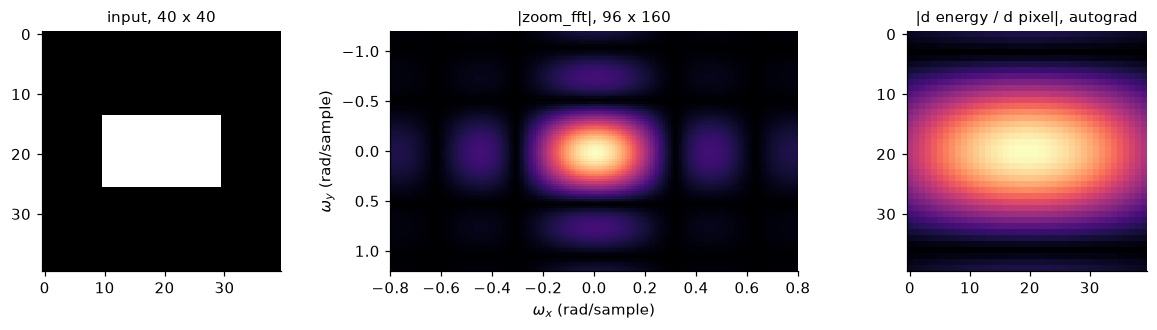

In [8]:
img = torch.zeros(40, 40, dtype=C64)
img[14:26, 10:30] = 1.0                                        # a 12 x 20 aperture
kw_img = dict(n_out=(96, 160), k_start=(-1.2, -0.8), k_end=(1.2, 0.8), dim=(-2, -1), center=True, norm="backward")
X_img = zoom_fft(img, **kw_img)

img_g = img.clone().requires_grad_(True)
window = zoom_fft(img_g, **kw_img)[40:56, 70:90]                # a window of the output
(window.abs() ** 2).sum().backward()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), gridspec_kw={"width_ratios": [1, 1.45, 1]})
axes[0].imshow(img.real, cmap="gray", interpolation="nearest"); axes[0].set_title("input, 40 x 40")
im = axes[1].imshow(X_img.abs(), extent=[-0.8, 0.8, 1.2, -1.2], cmap="magma", interpolation="nearest", aspect="auto")
axes[1].set(xlabel=r"$\omega_x$ (rad/sample)", ylabel=r"$\omega_y$ (rad/sample)", title="|zoom_fft|, 96 x 160")
axes[2].imshow(img_g.grad.abs(), cmap="magma", interpolation="nearest")
axes[2].set_title("|d energy / d pixel|, autograd")
for ax in axes:
    ax.grid(False)
fig.tight_layout()

xb = torch.randn(3, 12, 10, dtype=C128)
kw2 = dict(n_out=(8, 9), k_start=(-1.0, 0.3), k_end=(1.0, 2.0), norm="backward", center=(True, 4.5))
X2 = zoom_fft(xb, dim=(-2, -1), **kw2)
check("2-D == E1 x E2^T, per-axis band and origin", X2,
      fwd_matrix(12, 8, -1.0, 1.0, c=6) @ xb @ fwd_matrix(10, 9, 0.3, 2.0, c=4.5).T)
check("2-D == the two 1-D transforms in sequence", X2,
      zoom_fft(zoom_fft(xb, 8, -1.0, 1.0, dim=-2, norm="backward", center=True), 9, 0.3, 2.0, dim=-1, norm="backward", center=4.5))
check("batch axes untouched", X2[1], zoom_fft(xb[1], dim=(-2, -1), **kw2))
print("shape:", tuple(xb.shape), "->", tuple(X2.shape))

print(f"\n{'input':<12s}{'zoom_fft':<12s}{'zoom_ifft':<12s}czt")
for dt in (torch.float32, torch.float64, C64, C128):
    t = torch.randn(8, dtype=dt)
    nm = lambda v: str(v.dtype).replace("torch.", "")
    print(f"{nm(t):<12s}{nm(zoom_fft(t, 5, -1.0, 1.0)):<12s}{nm(zoom_ifft(t, 5, -1.0, 1.0)):<12s}{nm(czt(t, 5))}")
print()

xg = torch.randn(6, dtype=C128, requires_grad=True)
ok = torch.autograd.gradcheck(lambda t: zoom_fft(t, 8, -0.7, 1.1, center=True, include_end=True), (xg,))
note("torch.autograd.gradcheck through zoom_fft", "complex128", "pass" if ok else "FAIL")

if torch.backends.mps.is_available():
    p = torch.randn(2, 64, 64, dtype=C64)
    kw_m = dict(n_out=(128, 128), k_start=-0.5, k_end=0.5, dim=(-2, -1), center=True)
    check("MPS == CPU, (2, 64, 64) -> (2, 128, 128)", zoom_fft(p.to("mps"), **kw_m).cpu(), zoom_fft(p, **kw_m), label="complex64")
else:
    note("MPS", "-", "not available")

## Summary

In [9]:
w1 = max(len(n) for n, _, _ in CHECKS)
print(f"{'check':<{w1}s}  {'dtype':<11s}  result")
print("-" * (w1 + 24))
for name, label, value in CHECKS:
    print(f"{name:<{w1}s}  {label:<11s}  {value}")
print("-" * (w1 + 24))
print(f"{len(CHECKS)} checks")

check                                                 dtype        result
----------------------------------------------------------------------------
DFT == DTFT at w = 2 pi k / N                         complex128   1.05e-13
zoom_fft == E x (explicit summation)                  complex128   3.19e-13
zoom_fft == E x, complex64 input                      complex64    8.16e-06
zoom_fft == fft(x, n=256)[70:118]                     complex128   3.35e-14
zoom_fft == fft(x, n=1024)[300:364]                   complex128   2.56e-14
zoom_fft == fft(x, n=97)[11:41]                       complex128   1.42e-13
Bluestein re-derivation == O(NM) sum                  complex128   4.38e-13
library czt == O(NM) sum                              complex128   5.83e-13
zoom_fft == czt(w=-step, a=k_start) x ramp            complex128   8.88e-16
zoom_fft(x) == fft(x, norm='ortho')                   complex128   6.98e-15
band [-pi, pi) == fftshift(fft(x))                    complex128   1.55e-14
zoom_freq(8) 

[Notebook 1](01_why_zoom_fft.ipynb) shows why a pupil-to-PSF calculation needs a band and a sampling of its own. [Notebook 3](03_benchmark.ipynb) measures the cost of the zoom against a zero-padded FFT, the accuracy the float64 chirp phases buy, and the cases where the method is not the right choice.